# Extract conditions

## Packages, Fonts, Constants（パッケージ、フォント、定数）

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import PureWindowsPath
import os
import warnings
from datetime import datetime
import random

In [2]:
import platform
from matplotlib import rcParams

system = platform.system()

# OSごとにmatplotlibで使用するフォントを指定（システムになければフォントを追加する）
if system == "Windows":
    rcParams["font.family"] = "Meiryo"
elif system == "Darwin":  # macOS
    rcParams["font.family"] = "Hiragino Sans"
else:  # Linux
    rcParams["font.family"] = "IPAexGothic"

rcParams["font.size"] = 12

In [3]:
# condition list used in visualization
CONDITION_COLS = ['pretreatment_gas', 'pretreatment_flowrate',
       'pretreatment_time', 'pretreatment_temperature', 'setting_value_24', 'setting_value_25', 'setting_value_28', 'setting_value_29',
       'setting_value_31']

# aggregate_extracted_conditions()が返すDataFrameの列名を英語に変換するマッピング
COLUMN_NAME_MAP = {
    '測定者': 'operator',
    '装置': 'machine',
    'ファイルパス': 'filepath',
    'サンプル名': 'sample_name',
    'サンプル種類': 'sample_type',
    'サンプル重量': 'sample_weight',
    '前処理ガス': 'pretreatment_gas',
    '前処理流量': 'pretreatment_flowrate',
    '前処理時間': 'pretreatment_time',
    '前処理温度': 'pretreatment_temperature',
    '設定値24': 'setting_value_24',
    '設定値25': 'setting_value_25',
    '設定値28': 'setting_value_28',
    '設定値29': 'setting_value_29',
    '設定値31': 'setting_value_31',
    'パルス数': 'pulse_count',
    '測定値A8合計': 'measured_value_a8_total',
    '測定値A8合計（15回まで）': 'measured_value_a8_total_0to15',
    '測定値A8合計（15回まで） / 測定値A8合計': 'measured_value_a8_total_0to15_ratio',
    '測定値A8合計 / サンプル重量': 'measured_value_a8_total_per_weight',
    '測定値A8合計（15回まで） / サンプル重量': 'measured_value_a8_total_0to15_per_weight',
}

# サンプル名の種類
SAMPLE_TYPES = ['SampleA', 'SampleB', 'SampleC', 'SampleD', 'SampleE', 'SampleF']

# このノート由来の生成ファイルであることが分かるようにする出力先ルートフォルダ
OUTPUT_ROOT = "ExtractConditions"

# save summary as csv or noct
IS_SAVESUMMARY = True

# save graph as png or noct
IS_SAVEGRAPH = True

# save summary as pickle or noct
IS_SAVEPICKLE = True

# グラフのX軸の角度
XLABEL_ANGLE = 90

# ガス名を数値に変換する際のマッピング
GAS_MAP = {'Gas X': 0, 'Gas Y': 1, 'Gas Z': 2}

## Functions（関数）

In [4]:
import os
import shutil

def get_all_csv_files(directory):
    """
    指定されたディレクトリとそのすべてのサブディレクトリから
    CSVファイルのパスをリストとして取得する関数
    """
    csv_files = []
    
    # os.walkを使用して再帰的にディレクトリを探索
    for root, dirs, files in os.walk(directory):
        for file in files:
            # 拡張子が.csvのファイルだけをリストに追加
            if file.lower().endswith('.csv'):
                # ファイルの絶対パスを作成して追加
                csv_files.append(os.path.join(root, file))
    
    return csv_files

def get_methodA_data_files(directory):
    """
    指定されたディレクトリ以下のCSVファイルのうち、
    ・ファイル名に "MethodA" を含む
    ・ファイル名が "Trend" で始まらない
    ファイルのパスを取得する。
    """
    csv_files = []

    # ディレクトリを再帰的に探索
    for root, _, files in os.walk(directory):
        for file in files:
            basename = os.path.basename(file)

            # 条件を満たすCSVファイルのみ追加
            if (
                basename.lower().endswith(".csv")
                and "methoda" in basename.lower()
                and not basename.lower().startswith("trend")
            ):
                csv_files.append(os.path.join(root, file))

    return csv_files

def delete_csv_files_with_substring(directory, substring="after", dry_run=True):
    """
    指定されたディレクトリとそのすべてのサブディレクトリから
    特定の文字列を含むCSVファイルを削除する関数
    """
    files_to_delete = []
    
    # os.walkを使用して再帰的にディレクトリを探索
    for root, dirs, files in os.walk(directory):
        for file in files:
            # basenameを取得（ファイル名のみ）
            basename = os.path.basename(file)
            
            # 拡張子が.csvで、かつsubstringを含むファイルを対象にする
            if file.lower().endswith('.csv') and substring.lower() in basename.lower():
                file_path = os.path.join(root, file)
                files_to_delete.append(file_path)
                
                # dry_runがFalseの場合は実際にファイルを削除
                if not dry_run:
                    try:
                        os.remove(file_path)
                        print(f"削除しました: {file_path}")
                    except Exception as e:
                        print(f"削除に失敗しました: {file_path} - エラー: {str(e)}")
    
    # dry_runがTrueの場合は削除対象のファイルを表示
    if dry_run and files_to_delete:
        print(f"削除対象のファイル数: {len(files_to_delete)}")
        print("以下のファイルが削除対象です（dry_run=Falseに設定すると実際に削除されます）:")
        for file_path in files_to_delete:
            print(f"  {file_path}")
    
    return files_to_delete

In [5]:
def check_file_validity(file_path):
    """
    ファイルの有効性をチェックする関数
    
    Parameters:
    -----------
    file_path : str
        チェックするファイルのパス
        
    Returns:
    --------
    bool
        ファイルが有効な場合はTrue、そうでない場合はFalse
    str or None
        エラーメッセージ（エラーがある場合）、なければNone
    """
    if not os.path.exists(file_path):
        return False, f"ファイル '{file_path}' は存在しません。"
        
    if os.path.isdir(file_path):
        return False, f"'{file_path}' はディレクトリです。CSVファイルのパスを指定してください。"
        
    if not file_path.lower().endswith('.csv'):
        return False, f"'{file_path}' はCSVファイルではありません。"
        
    if not os.access(file_path, os.R_OK):
        return False, f"'{file_path}' には読み取り権限がありません。"
    
    return True, None

In [6]:
def _dataframe_section(raw_df, headnum, usecols):
    """
    raw_df（get_header_positions等と同じくnames=range(0, 15)で読み込んだ生データ）から、
    pd.read_csv(file, header=headnum, usecols=usecols)相当の部分DataFrameを、
    ディスクを再度読まずに切り出す。
    """
    sub = raw_df.iloc[headnum:, list(usecols)].reset_index(drop=True)
    new_columns = sub.iloc[0]
    sub = sub.iloc[1:].reset_index(drop=True)
    sub.columns = new_columns
    return sub


def get_header_positions(file: str = None, raw_df=None):
    """取得したいデータが記載されている箇所のヘッダー位置を取得"""
    if raw_df is None:
        raw_df = pd.read_csv(file, names=range(0, 15), encoding='shift_jis')

    row_numbers = {
        '保存ファイル名': None,
        '前処理開始日時': None,
        'STEP': None,
        '設定値0': None,
        '測定開始日時': None,
        '測定値A1': None,
        '測定結果8': None
    }

    for key in row_numbers:
        row_number = int(raw_df[raw_df[1] == key].index[0]) if not raw_df[raw_df[1] == key].empty else None
        row_numbers[key] = row_number

    return row_numbers


def load_and_extract_sampleinfo(file: str, headnum: int | None = None, raw_df=None):
    """装置、サンプル名などの情報を取得"""
    # Noneの場合、デフォルト値14を使用
    if headnum is None:
        headnum = 14

    basefilename = os.path.basename(file)

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 3))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 3), encoding='shift_jis')

        # extract who's folder
        filepath = df.columns[1]

        path = PureWindowsPath(filepath)
        name = path.parts[3] if len(path.parts) > 3 else np.nan

        # Which machine was used (MachineA or MachineB)
        which_machine = path.parts[1]

        # extract sample name, weight
        sample_name_rows = df[df['保存ファイル名'] == 'サンプル名']
        sample_name = sample_name_rows.iloc[0, 1] if not sample_name_rows.empty else np.nan

        sample_weight_rows = df[df['保存ファイル名'] == 'サンプル重量']
        sample_weight = float('0' + sample_weight_rows.iloc[0, 1]) if not sample_weight_rows.empty else np.nan

        # サンプル種類を判定
        sample_type = 'others'  # デフォルト値
        file_lower = basefilename.lower()  # 大文字小文字を区別しない

        # 指定されたワードとサンプル種類の対応をチェック
        for candidate in SAMPLE_TYPES:
            if candidate.lower() in file_lower:
                sample_type = candidate
                break

    except Exception:
        name = np.nan
        which_machine = np.nan
        filepath = np.nan
        sample_name = np.nan
        sample_weight = np.nan
        sample_type = 'others'

    return {
        '測定者': name,
        '装置': which_machine,
        'ファイルパス': filepath,
        'サンプル名': sample_name,
        'サンプル種類': sample_type,
        'サンプル重量': sample_weight
    }


def load_and_extract_date(file: str = None, headnum: int | None = None, raw_df=None):
    """前処理開始日時（C25）を取得"""
    # Noneの場合、デフォルト値24を使用
    if headnum is None:
        headnum = 24

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 3))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 3), encoding='shift_jis')
        date = df.columns[1].replace('#', '')
        parsed_date = pd.to_datetime(date)
    except Exception:
        parsed_date = np.nan

    return {'date': parsed_date}

def df_pretreatment_sequence(file: str = None, headnum: int | None = None, raw_df=None):
    """前処理シークエンスのデータを取得"""
    # Noneの場合、デフォルト値27を使用
    if headnum is None:
        headnum = 27
    cols = ['STEP', 'ガス', '流量', '時間', '温度', 'X機構']

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 7))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 7), encoding='shift_jis')
        df.columns = cols

        # 全列がNaNになる最初の行（ステップ記録の終端）までを取得
        blank_rows = df.index[df.isna().all(axis=1)]
        if len(blank_rows) > 0:
            df = df.iloc[:blank_rows[0]]

        df['STEP'] = df['STEP'].astype(int)

        for row in ['流量', '時間', '温度']:
            df[row] = df[row].astype(float)
    except Exception:
        # 例外が発生した場合は、空のDataFrameを返す
        df = pd.DataFrame(columns=cols)

    return df

def load_and_extract_pretreatment_conditions(file: str = None, headnum: int | None = None, step: int = 3, raw_df=None):
    """前処理ステップのSTEP3の条件を前処理条件として取得"""
    conditions = {
        '前処理ガス': np.nan,
        '前処理流量': np.nan,
        '前処理時間': np.nan,
        '前処理温度': np.nan,
    }

    try:
        df = df_pretreatment_sequence(file, headnum=headnum, raw_df=raw_df)

        for row in ['ガス', '流量', '時間', '温度']:
            value = df[df['STEP'] == step][row].iloc[0]
            conditions[f'前処理{row}'] = value
    except Exception:
        # 例外が発生した場合は、すでにnp.nanで初期化されているのでそのまま返す
        pass

    return conditions


def load_and_extract_pulse_condition(file: str = None, headnum: int | None = None, raw_df=None):
    """測定パラメータを取得"""
    # Noneの場合、デフォルト値37を使用
    if headnum is None:
        headnum = 37

    result = {
        '設定値24': np.nan,
        '設定値25': np.nan,
        '設定値28': np.nan,
        '設定値29': np.nan,
        '設定値31': np.nan,
        'パルス数': np.nan
    }

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 3))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 3), encoding='shift_jis')

        # 各項目について、該当する行が存在する場合のみ値を取得
        for key in result:
            target_row = df[df['設定値0'] == key]
            if not target_row.empty:
                result[key] = int(target_row.iloc[0, 1])
    except Exception:
        # 例外が発生した場合は、すでにnp.nanで初期化されているのでそのまま返す
        pass

    return result

def load_and_extract_chemosorption(file: str = None, sample_weight: float = np.nan, headnum: int | None = None, lastrownum: int | None = None, raw_df=None):
    """測定結果を取得"""
    # Noneの場合、デフォルト値を使用
    if headnum is None:
        headnum = 80
    if lastrownum is None:
        lastrownum = 130

    result = {
        '測定値A8合計': np.nan, # 測定結果3（C100）に記載されている、装置側で算出した測定値A8の合計
        '測定値A8合計 / サンプル重量': np.nan,
        '測定値A8合計（15回まで）': np.nan, # 15回までの測定における測定値A8の合計
        '測定値A8合計（15回まで） / サンプル重量': np.nan,
        '測定値A8合計（15回まで） / 測定値A8合計': np.nan,
    }

    try:
        if raw_df is not None:
            df = _dataframe_section(raw_df, headnum, range(1, 15))
        else:
            df = pd.read_csv(file, header=headnum, usecols=range(1, 15), encoding='shift_jis')
        df = df.head(lastrownum - headnum)

        total_rows = df[df['測定値A1'] == '測定結果3']
        if not total_rows.empty and '測定値A2' in total_rows.columns:
            measured_value_a8_total = float('0' + total_rows['測定値A2'].iloc[0])
            result['測定値A8合計'] = measured_value_a8_total

            if pd.notna(sample_weight) and sample_weight != 0:
                result['測定値A8合計 / サンプル重量'] = measured_value_a8_total / sample_weight

            if '測定値A8' in df.columns:
                measured_value_a8_total_0to15 = float(df['測定値A8'][0:16].astype(float).sum())
                result['測定値A8合計（15回まで）'] = measured_value_a8_total_0to15

                if measured_value_a8_total != 0:
                    result['測定値A8合計（15回まで） / 測定値A8合計'] = measured_value_a8_total_0to15 / measured_value_a8_total

                if pd.notna(sample_weight) and sample_weight != 0:
                    result['測定値A8合計（15回まで） / サンプル重量'] = measured_value_a8_total_0to15 / sample_weight
    except Exception:
        # 例外が発生した場合は、すでにnp.nanで初期化されているのでそのまま返す
        pass

    return result

def aggregate_extracted_conditions(file_list):
    """ファイルのリストから条件や結果を収集しデータフレームにまとめる"""
    data = []
    error_files = []

    for file in file_list:
        # ファイルの事前チェック
        is_valid, error_message = check_file_validity(file)
        if not is_valid:
            error_files.append([file, error_message])
            continue

        try:
            # ファイルを1回だけ読み込み、以降の抽出処理はディスクを再度読まずに使い回す
            raw_df = pd.read_csv(file, names=range(0, 15), encoding='shift_jis')

            # get header row numbers of each data area
            headers = get_header_positions(raw_df=raw_df)

            # dictionary for conditions
            conditions = {}

            # collect each condition data
            sample_info = load_and_extract_sampleinfo(file, headers['保存ファイル名'], raw_df=raw_df)
            date = load_and_extract_date(file, headers['前処理開始日時'], raw_df=raw_df)
            pretreatment_condition = load_and_extract_pretreatment_conditions(file, headers['STEP'], raw_df=raw_df)
            purge_condition = load_and_extract_pulse_condition(file, headers['設定値0'], raw_df=raw_df)
            chemosorption_amount = load_and_extract_chemosorption(file, sample_info['サンプル重量'], headers['測定値A1'], headers['測定結果8'], raw_df=raw_df)

            # integrate each condition data to one dictionary
            for part in [sample_info, date, pretreatment_condition, purge_condition, chemosorption_amount]:
                conditions.update(part)

            # add to data array
            data.append(conditions)
        except Exception as e:
            # エラーが発生した場合は警告を出力してスキップ
            # warnings.warn(f"ファイル '{file}' の処理中にエラーが発生しました: {str(e)}. このファイルはスキップします。")
            error_files.append([file, str(e)])
            continue

    if not data:
        warnings.warn("有効なデータが1つも処理できませんでした。空のDataFrameを返します。")

    df = pd.DataFrame(data)
    df = df.rename(columns=COLUMN_NAME_MAP)

    return df, pd.DataFrame(error_files, columns=['filename', 'error_detail'])


In [7]:
def plot_multiple_temperature_profiles(files, labels=None, colors=None, initial_temp=25, figsize=(12, 7), is_who_included: bool = False):
    """前処理の条件のトレンドを可視化"""
    dfs = [df_pretreatment_sequence(file) for file in files]
    
    # デフォルトの色とラベルの設定
    if colors is None:
        colors = plt.cm.tab10.colors  # matplotlibのデフォルトカラーマップ
    
    if labels is None:
        labels = [os.path.basename(file) for file in files]
    
    # グラフの作成
    fig, ax = plt.subplots(figsize=figsize)
    
    # 各データフレームに対して処理
    for i, df in enumerate(dfs):
        try:
            # 色の選択（循環させる）
            color = colors[i % len(colors)]
            
            # 累積時間の計算
            df_copy = df.copy()
            df_copy['累積時間'] = df_copy['時間'].cumsum()
            
            # 時間と温度のポイントを作成
            time_points = [0]  # 開始時点（0分）
            temp_points = [initial_temp]  # 開始温度
            
            for _, row in df_copy.iterrows():
                time_points.append(row['累積時間'])
                temp_points.append(row['温度'])
            
            # プロット
            ax.plot(time_points, temp_points, '-o', color=color, linewidth=2, 
                    label=labels[i], markersize=6)
        except:
            continue
    
    # グラフの装飾
    ax.set_xlabel('時間', fontsize=12)
    ax.set_ylabel('温度', fontsize=12)
    ax.set_title('前処理条件における時間に対する温度の比較', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    # ax.legend(loc='best')
    ax.legend(bbox_to_anchor=(1.05, 0.95), loc='upper left')
    
    plt.tight_layout()
    return fig

## Get filtered datafiles（必要なデータのリストを取得する）

In [8]:
# 使用例
directory_path = "Data/dummy_data"  # 検索したいディレクトリのパスを指定

# すべてのCSVファイルを取得
all_csv_files = get_all_csv_files(directory_path)

# 条件に合わないCSVファイルを取得
filtered_csv_files = get_methodA_data_files(directory_path)

# 結果の表示
print(f"すべてのCSVファイル数: {len(all_csv_files)}")
print(f"フィルタリング後のCSVファイル数: {len(filtered_csv_files)}")
print("\nフィルタリング後のCSVファイル一覧:")
print("省略")

すべてのCSVファイル数: 4000
フィルタリング後のCSVファイル数: 1000

フィルタリング後のCSVファイル一覧:
省略


## Extract conditions from csv files（CSVファイルからのデータ抽出）

### File check

In [9]:
# ヘッダー位置の確認
rng = np.random.default_rng(42)
for i in range(10):
    try:
        file = rng.choice(filtered_csv_files)
        headers = get_header_positions(file)
        print(file)
        print(headers)
    except:
        print("failed to load header")

Data/dummy_data/MachineB/UserE/MethodA/sampleC_300321-MethodA-300416-1611.csv
{'保存ファイル名': 14, '前処理開始日時': 24, 'STEP': 27, '設定値0': 37, '測定開始日時': 74, '測定値A1': 80, '測定結果8': 104}
Data/dummy_data/MachineA/UserO/MethodA/sampleD_270922-MethodA-270923-1032.csv
{'保存ファイル名': 14, '前処理開始日時': 24, 'STEP': 27, '設定値0': 37, '測定開始日時': 74, '測定値A1': 80, '測定結果8': 104}
Data/dummy_data/MachineA/UserC/MethodA/sampleD_291207-MethodA-291222-1440.csv
{'保存ファイル名': 14, '前処理開始日時': 24, 'STEP': 27, '設定値0': 37, '測定開始日時': 74, '測定値A1': 80, '測定結果8': 104}
Data/dummy_data/MachineB/UserI/MethodA/sampleB_291101-MethodA-291114-1740.csv
{'保存ファイル名': 14, '前処理開始日時': 24, 'STEP': 27, '設定値0': 37, '測定開始日時': 74, '測定値A1': 80, '測定結果8': 104}
Data/dummy_data/MachineB/UserI/MethodA/sampleE_240204-MethodA-240205-1357.csv
{'保存ファイル名': 14, '前処理開始日時': 24, 'STEP': 27, '設定値0': 37, '測定開始日時': 74, '測定値A1': 80, '測定結果8': 104}
Data/dummy_data/MachineA/UserA/MethodA/sampleB_240513-MethodA-240514-1639.csv
{'保存ファイル名': 14, '前処理開始日時': 24, 'STEP': 27, '設定値0': 3

In [10]:
# ディレクトリやCSVファイル以外のファイルが含まれていないかチェック
for file in filtered_csv_files:
    if os.path.isdir(file):
        print(f"{file} はディレクトリです")
    elif not file.lower().endswith('.csv'):
        print(f"{file} はCSVファイルではありません")

In [11]:
# パスの存在と読み取り権限の確認
for file in filtered_csv_files:
    if not os.path.exists(file):
        print(f"{file} は存在しません")
    elif not os.access(file, os.R_OK):
        print(f"{file} には読み取り権限がありません")

### Extract conditions from MethodA csv files

In [12]:
df, error_df = aggregate_extracted_conditions(filtered_csv_files)
df

,operator,machine,filepath,sample_name,sample_type,sample_weight,date,pretreatment_gas,pretreatment_flowrate,pretreatment_time,...,setting_value_25,setting_value_28,setting_value_29,setting_value_31,pulse_count,measured_value_a8_total,measured_value_a8_total_per_weight,measured_value_a8_total_0to15,measured_value_a8_total_0to15_per_weight,measured_value_a8_total_0to15_ratio
0,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleD_250918-...,sampleD_250918-MethodA-251020-1452,SampleD,1.0,2025-10-20 12:00:00,Gas X,40.0,30.0,...,60,10,20,12,12,3325.1406,3325.1406,3325.1406,3325.1406,1.0
1,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleF_261116-...,sampleF_261116-MethodA-261202-1446,SampleF,1.0,2026-12-02 12:00:00,Gas X,40.0,30.0,...,60,10,20,16,16,3607.0326,3607.0326,3607.0326,3607.0326,1.0
2,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleE_200921-...,sampleE_200921-MethodA-201011-0818,SampleE,1.0,2020-10-11 12:00:00,Gas X,20.0,30.0,...,60,10,20,12,12,2191.4414,2191.4414,2191.4414,2191.4414,1.0
3,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleB_201019-...,sampleB_201019-MethodA-201129-1713,SampleB,1.0,2020-11-29 12:00:00,Gas X,30.0,30.0,...,60,10,20,12,12,2141.3897,2141.3897,2141.3897,2141.3897,1.0
4,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleA_200105-...,sampleA_200105-MethodA-200106-0924,SampleA,1.0,2020-01-06 12:00:00,Gas X,45.0,30.0,...,60,10,20,12,12,2192.9189,2192.9189,2192.9189,2192.9189,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,UserN,MachineA,C:/MachineA/DATA/UserN/MethodA/sampleF_230512-...,sampleF_230512-MethodA-230513-1547,SampleF,1.0,2023-05-13 12:00:00,Gas Z,40.0,30.0,...,60,10,20,16,16,3546.3808,3546.3808,3546.3808,3546.3808,1.0
996,UserN,MachineA,C:/MachineA/DATA/UserN/MethodA/sampleB_280803-...,sampleB_280803-MethodA-280804-1805,SampleB,1.0,2028-08-04 12:00:00,Gas Z,70.0,30.0,...,60,10,20,16,16,3431.5525,3431.5525,3431.5525,3431.5525,1.0
997,UserN,MachineA,C:/MachineA/DATA/UserN/MethodA/sampleC_220714-...,sampleC_220714-MethodA-220715-1344,SampleC,1.0,2022-07-15 12:00:00,Gas Z,70.0,30.0,...,60,10,20,16,16,3518.6802,3518.6802,3518.6802,3518.6802,1.0
998,UserN,MachineA,C:/MachineA/DATA/UserN/MethodA/sampleF_280206-...,sampleF_280206-MethodA-280207-1502,SampleF,1.0,2028-02-07 12:00:00,Gas Z,45.0,30.0,...,60,10,20,16,16,3178.8028,3178.8028,3178.8028,3178.8028,1.0


### List of error files

In [13]:
# files that encountered error
error_df

,filename,error_detail


### List of data as "others"（sample_typeが意図したカテゴリに分離されたサンプルがないかをチェック）

In [14]:
df['sample_type'].value_counts()

sample_type
SampleB    181
SampleF    177
SampleE    177
SampleD    171
SampleC    148
SampleA    146
Name: count, dtype: int64

In [15]:
sample_categorized_others_df = df[df['sample_type'] == 'others']['sample_name'].value_counts()
sample_categorized_others_df

Series([], Name: count, dtype: int64)

## Clea data

### Filter unknown users' rows from df（不明なユーザー名のデータ行を除外する）

In [16]:
df['operator'].unique()

<StringArray>
['UserK', 'UserL', 'UserE', 'UserB', 'UserC', 'UserD', 'UserM', 'UserJ',
 'UserO', 'UserH', 'UserA', 'UserF', 'UserG', 'UserI', 'UserN']
Length: 15, dtype: str

### operatorに不明なユーザー名のデータが存在する（仮定）ので除外

In [17]:
# a list of values to exclude
exclusion_users = ['exclude_keyword1', 'exclude_keyword2', 
                     'exclude_keyword3', 'exclude_keyword4']

# Filter the DataFrame to keep only rows where column "operator" is NOT in the list
df_cleaned = df.copy()
df_cleaned = df[~df['operator'].isin(exclusion_users)]


### どのくらい除外されたかを確認

In [18]:
df.shape, df_cleaned.shape

((1000, 22), (1000, 22))

In [19]:
df_cleaned['operator'].unique()

<StringArray>
['UserK', 'UserL', 'UserE', 'UserB', 'UserC', 'UserD', 'UserM', 'UserJ',
 'UserO', 'UserH', 'UserA', 'UserF', 'UserG', 'UserI', 'UserN']
Length: 15, dtype: str

### Standarize notation（表記違いのユーザーの表記を統一、前処理条件0からの半角スペースの削除）

In [20]:
df_cleaned['operator'] = df_cleaned['operator'].str.replace("Userc", "UserC")
df_cleaned['operator'].value_counts()

operator
UserO    78
UserB    74
UserM    74
UserC    73
UserJ    70
UserG    67
UserK    66
UserA    66
UserE    64
UserF    64
UserH    63
UserI    62
UserL    61
UserD    61
UserN    57
Name: count, dtype: int64

In [21]:
df_cleaned['pretreatment_gas'] = df_cleaned['pretreatment_gas'].str.strip(" ")
df_cleaned['pretreatment_gas'].value_counts()

pretreatment_gas
Gas X    885
Gas Y     60
Gas Z     55
Name: count, dtype: int64

### どのくらい除外されたかを確認

In [22]:
df.shape, df_cleaned.shape

((1000, 22), (1000, 22))

## save extracted data as CSV file（抽出したデータをCSVとして保存）

In [23]:
if IS_SAVESUMMARY:
    # create directory
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    timestamp_dir = os.path.join(OUTPUT_ROOT, "summary_table", f"Summary_created{current_time}")
    os.makedirs(timestamp_dir, exist_ok=True)
    
    try:
        savepath = os.path.join(timestamp_dir, "extracted_condtion_and_data.csv")
        df_cleaned.to_csv(savepath, encoding="shift_jis")
    finally:
        print("Export summary to csv")

    try:
        savepath_sample_categorized_others_df = os.path.join(timestamp_dir, "sample_categorized_others_df.csv")
        sample_categorized_others_df.to_csv(savepath_sample_categorized_others_df, encoding="shift_jis")
    finally:
        print("Export list of categorized as others to csv")

    try:
        savepath_errorfiles = os.path.join(timestamp_dir, "error_files.csv")
        error_df.to_csv(savepath_errorfiles, encoding="shift_jis")
    finally:
        print("Export error files list to csv")
    
    print("saved!")

Export summary to csv
Export list of categorized as others to csv
Export error files list to csv
saved!


### Pickleファイルとして保存

In [24]:
# 現在日時を取得
now = datetime.now().strftime("%Y%m%d_%H%M%S")

# ファイル名作成
filename = os.path.join(OUTPUT_ROOT, f"Pickle/condition_df_{now}.pkl")

# 保存
if IS_SAVEPICKLE:
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    df_cleaned.to_pickle(filename)
    print(f"Pickle saved: {filename}")

Pickle saved: ExtractConditions/Pickle/condition_df_20260807_083028.pkl


## Investigate the effects of pulse times（参考：最大パルス設定値が15未満であった測定の調査）

In [25]:
df_cleaned['measured_value_a8_total_0to15_ratio'].mean() * 100

np.float64(99.81568821286949)

In [26]:
df_cleaned_pulseover15 = df_cleaned[df_cleaned['setting_value_31'] > 15]
df_cleaned_pulseover15.head()

,operator,machine,filepath,sample_name,sample_type,sample_weight,date,pretreatment_gas,pretreatment_flowrate,pretreatment_time,...,setting_value_25,setting_value_28,setting_value_29,setting_value_31,pulse_count,measured_value_a8_total,measured_value_a8_total_per_weight,measured_value_a8_total_0to15,measured_value_a8_total_0to15_per_weight,measured_value_a8_total_0to15_ratio
1,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleF_261116-...,sampleF_261116-MethodA-261202-1446,SampleF,1.0,2026-12-02 12:00:00,Gas X,40.0,30.0,...,60,10,20,16,16,3607.0326,3607.0326,3607.0326,3607.0326,1.0
9,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleD_220921-...,sampleD_220921-MethodA-220922-1124,SampleD,1.0,2022-09-22 12:00:00,Gas X,25.0,30.0,...,60,10,20,16,16,2281.1128,2281.1128,2281.1128,2281.1128,1.0
10,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleC_300327-...,sampleC_300327-MethodA-300417-1216,SampleC,1.0,2030-04-17 12:00:00,Gas X,50.0,30.0,...,60,10,20,16,16,2344.3581,2344.3581,2344.3581,2344.3581,1.0
16,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleD_240323-...,sampleD_240323-MethodA-240324-1553,SampleD,1.0,2024-03-24 12:00:00,Gas X,25.0,30.0,...,60,10,20,16,16,2551.8031,2551.8031,2551.8031,2551.8031,1.0
18,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleD_220727-...,sampleD_220727-MethodA-220904-1859,SampleD,1.0,2022-09-04 12:00:00,Gas X,30.0,40.0,...,60,10,20,16,16,2672.8136,2672.8136,2672.8136,2672.8136,1.0


In [27]:
df_cleaned.shape, df_cleaned_pulseover15.shape

((1000, 22), (817, 22))

## Compare pretreatment trend（前処理トレンドを可視化）

参考として実データがどのような前処理温度トレンドとなっていたかを確認

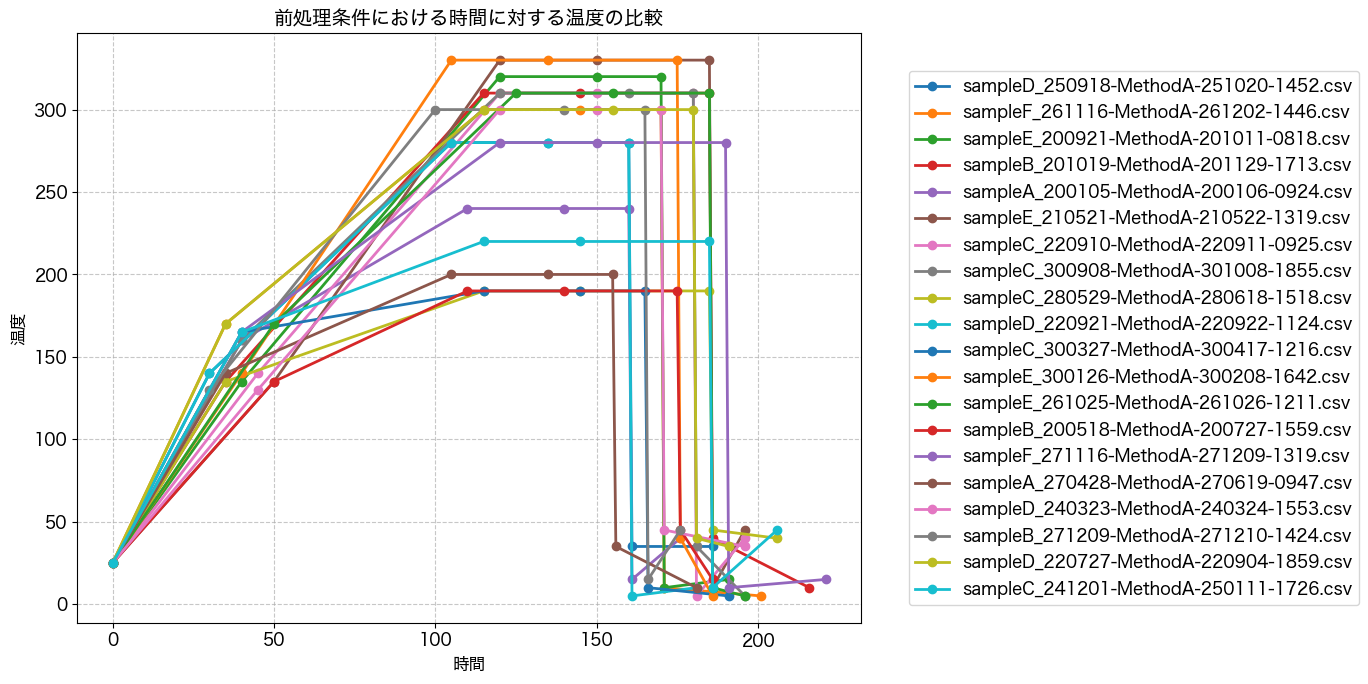

In [28]:
fig = plot_multiple_temperature_profiles(filtered_csv_files[:20], figsize=(14, 7))
plt.show()

## 最大パルス数設定値の影響

### 最大パルス数（設定値）の分布

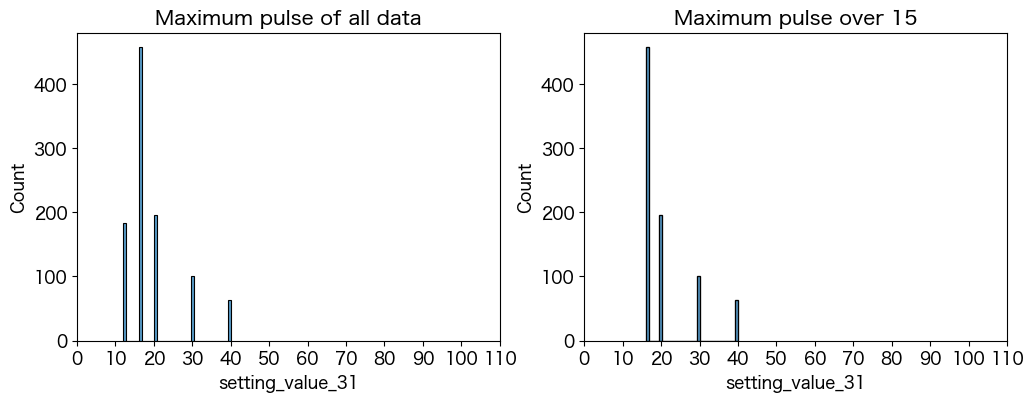

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_cleaned, x='setting_value_31', ax=axs[0])
sns.histplot(df_cleaned_pulseover15, x='setting_value_31', ax=axs[1])

axs[0].set_title("Maximum pulse of all data")
axs[1].set_title("Maximum pulse over 15")

axs[0].set_xticks(range(0, 120, 10))
axs[1].set_xticks(range(0, 120, 10))
plt.show()

### 最大パルス数15未満と15以上で測定値A8の合計に差が生まれていないかを確認

In [30]:
# 各列の平均値を計算
mean_values = df_cleaned_pulseover15[['measured_value_a8_total', 'measured_value_a8_total_0to15']].mean()

mean_total = mean_values['measured_value_a8_total']
mean_0to15 = mean_values['measured_value_a8_total_0to15']

print(f"測定値A8合計: {mean_total:.4f}")
print(f"測定値A8合計 (パルス15まで): {mean_0to15:.4f}")

ratio = 100 * mean_0to15 / mean_total
print(f"測定値A8（パルス15までは）は全測定値A8に対し{ratio:.2f}%")

mean_weight = df_cleaned_pulseover15['sample_weight'].mean()
print(f'平均サンプル重量: {mean_weight:.5f}')

vm_total = mean_total / mean_weight
vm_0to15 = mean_0to15 / mean_weight

print(f"重量あたり測定値A8合計: {(vm_total):.4f}")
print(f"重量あたり測定値A8合計 (パルス15まで): {(vm_0to15):.4f}")

print(f"測定値A8（パルス15までは）は全測定値A8に対し{100 * vm_0to15 / vm_total:.2f}%")

測定値A8合計: 2855.5518
測定値A8合計 (パルス15まで): 2848.2460
測定値A8（パルス15までは）は全測定値A8に対し99.74%
平均サンプル重量: 1.00000
重量あたり測定値A8合計: 2855.5518
重量あたり測定値A8合計 (パルス15まで): 2848.2460
測定値A8（パルス15までは）は全測定値A8に対し99.74%


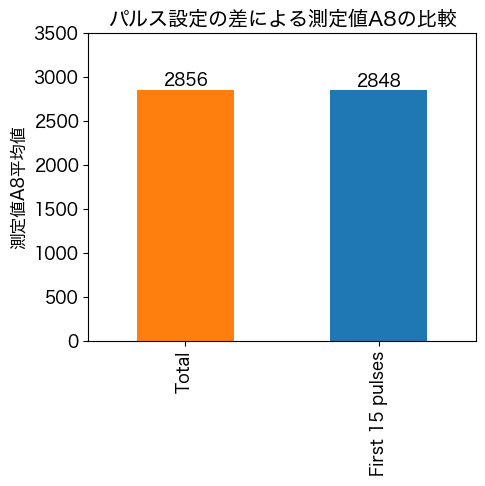

In [31]:
# 棒グラフの作成
plt.figure(figsize=(5, 4))
mean_values = mean_values.rename(index={
    'measured_value_a8_total': 'Total',
    'measured_value_a8_total_0to15': 'First 15 pulses',
})
mean_values.plot(kind='bar', color=['C1', 'C0'])

# グラフのタイトルと軸ラベルを設定
plt.title('パルス設定の差による測定値A8の比較')
plt.ylabel('測定値A8平均値')
plt.ylim(0, 3500)

# 各バーの上に値を表示（オプション）
for i, value in enumerate(mean_values):
    plt.text(i, value, f'{value:.0f}', ha='center', va='bottom')

# plt.tight_layout()
plt.show()


## Extract SampleA or SampleB sample's data (SampleAとSampleBのデータだけ抽出（sampleA_sampleB_df）

In [32]:
df_cleaned['sample_type'].unique()

<StringArray>
['SampleD', 'SampleF', 'SampleE', 'SampleB', 'SampleA', 'SampleC']
Length: 6, dtype: str

In [33]:
# a list of values to include
inclusion_samples = ['SampleA', 'SampleB']

# Filter the DataFrame to keep only SampleA or SampleB columns
sampleA_sampleB_df = df_cleaned.copy()
sampleA_sampleB_df = df_cleaned[df_cleaned['sample_type'].isin(inclusion_samples)]

In [34]:
sampleA_sampleB_df['sample_type'].unique()

<StringArray>
['SampleB', 'SampleA']
Length: 2, dtype: str

### どのくらい除外されたかを確認

In [35]:
df.shape, df_cleaned.shape, sampleA_sampleB_df.shape

((1000, 22), (1000, 22), (327, 22))

### CSVとして保存

In [36]:
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")

if IS_SAVESUMMARY:
    os.makedirs(os.path.join(OUTPUT_ROOT, "summary_table/filtered_SampleAandSampleB"), exist_ok=True)
    sampleA_sampleB_df.to_csv(
        os.path.join(OUTPUT_ROOT, f"summary_table/filtered_SampleAandSampleB/filtered_onlySampleAandSampleB_created{current_time}.csv"),
        encoding="shift_jis"
    )

## Visualization（SampleAとSampleBのデータの可視化）

### ユーザーごとの前処理条件の内訳をヒートマップで可視化

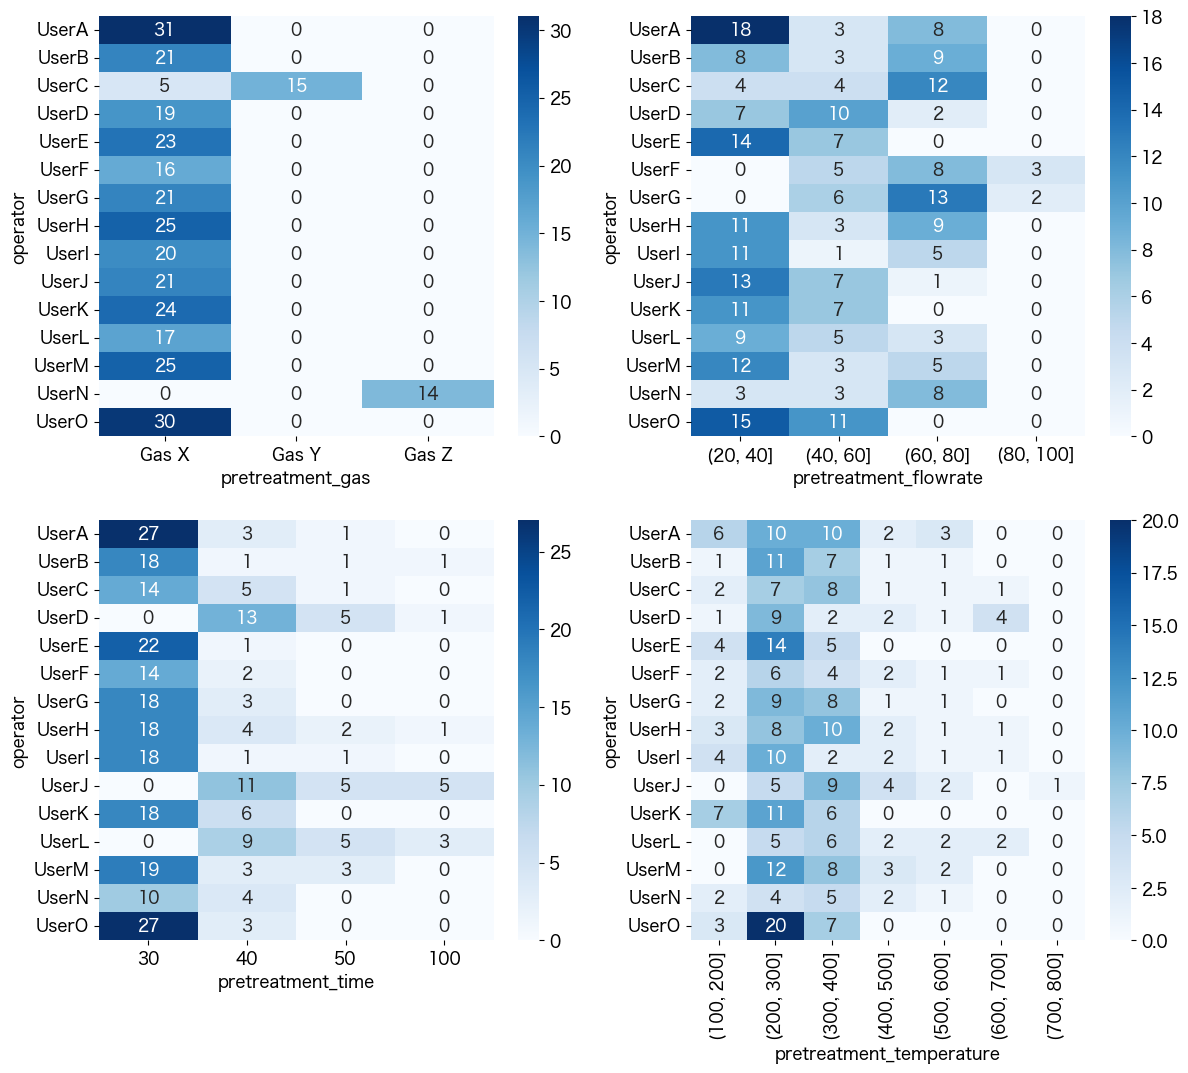

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.ravel()

target_conditions = ['pretreatment_gas', 'pretreatment_flowrate', 'pretreatment_time', 'pretreatment_temperature']

# ユニーク値が多い連続値の項目は、pivotする前にこの幅でビンにまとめて列数を減らす
BIN_WIDTHS = {'pretreatment_temperature': 100, 'pretreatment_flowrate': 20}

for ax, target in zip(axs, target_conditions):
    bin_width = BIN_WIDTHS.get(target)
    if bin_width is None:
        pivot_columns = target
    else:
        col_min = sampleA_sampleB_df[target].min()
        col_max = sampleA_sampleB_df[target].max()
        bin_start = int(col_min // bin_width * bin_width)
        bin_end = int(col_max // bin_width * bin_width) + bin_width * 2
        pivot_columns = pd.cut(sampleA_sampleB_df[target], bins=range(bin_start, bin_end, bin_width))

    sampleA_sampleB_pivot = pd.pivot_table(
        sampleA_sampleB_df,
        index="operator",
        columns=pivot_columns,
        aggfunc="size",
        fill_value=0,
    )
    if pd.api.types.is_numeric_dtype(sampleA_sampleB_pivot.columns):
        sampleA_sampleB_pivot.columns = sampleA_sampleB_pivot.columns.astype(int)
    sns.heatmap(sampleA_sampleB_pivot, annot=True, cmap="Blues", ax=ax)
    
plt.show()

### いろいろな測定条件についてユーザーごとに棒グラフで可視化

#### Compare averages using a bar chart

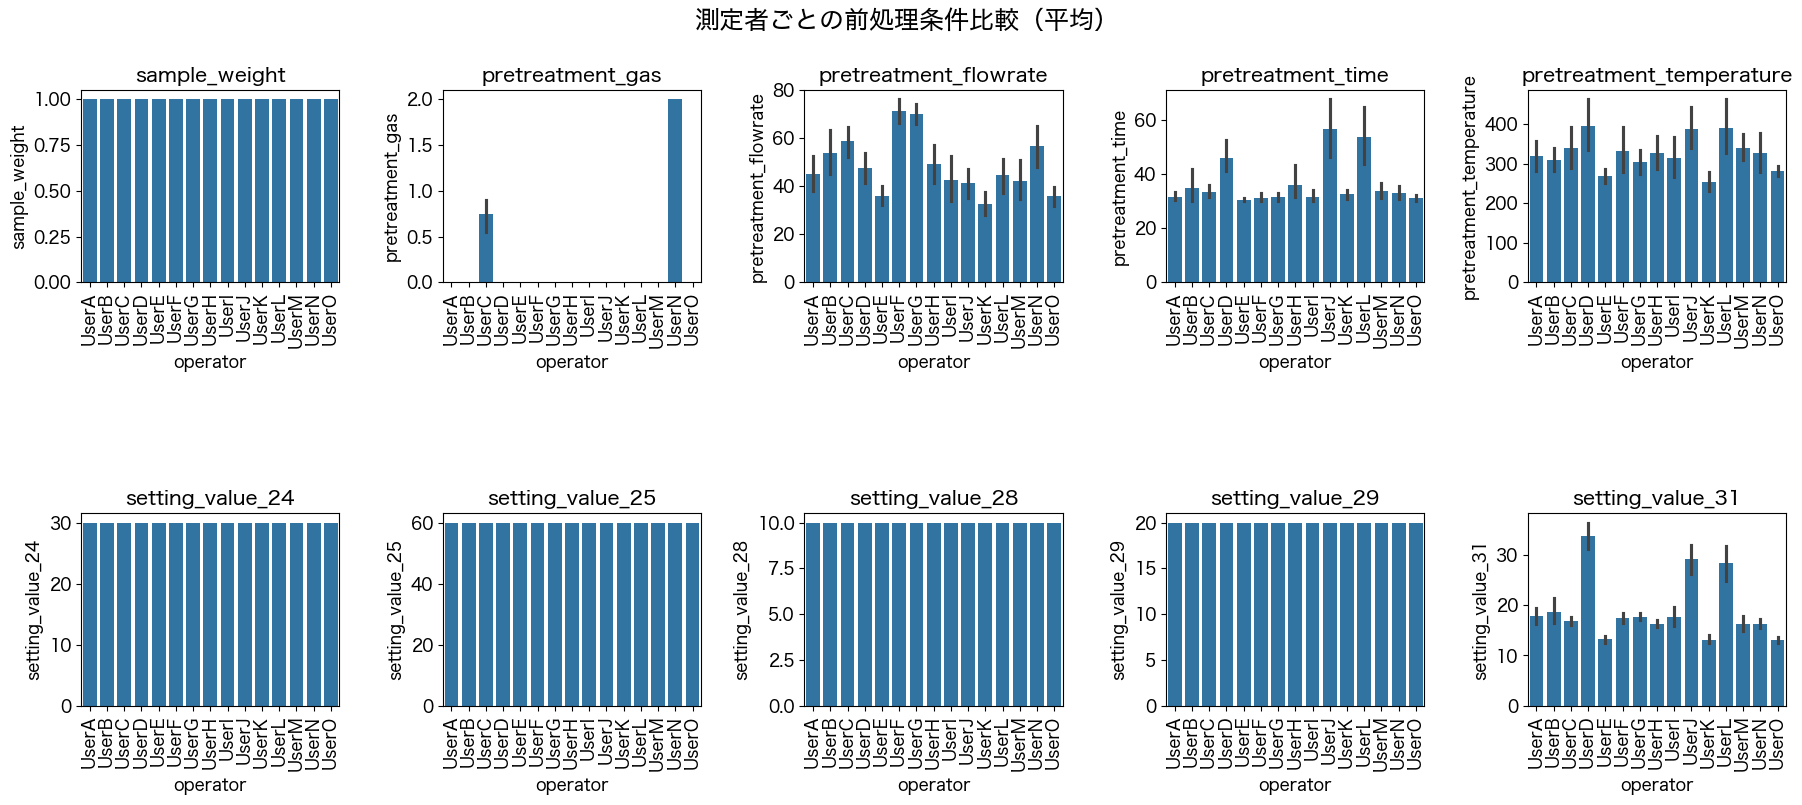

In [38]:
fig, axs = plt.subplots(2, 5, figsize=(22, 8))

parsed_sampleA_sampleB_df = sampleA_sampleB_df.copy()
parsed_sampleA_sampleB_df['pretreatment_gas'] = parsed_sampleA_sampleB_df['pretreatment_gas'].map(GAS_MAP)

conditions1 = ['sample_weight', 'pretreatment_gas', 'pretreatment_flowrate', 'pretreatment_time', 'pretreatment_temperature']
conditions2 = ['setting_value_24', 'setting_value_25', 'setting_value_28', 'setting_value_29', 'setting_value_31']
operator_order = sorted(parsed_sampleA_sampleB_df['operator'].unique())

for i, condition in enumerate(conditions1):
    sns.barplot(parsed_sampleA_sampleB_df, x='operator', y=condition, order=operator_order, ax=axs[0, i])
    axs[0, i].set_title(condition)
    axs[0, i].tick_params(axis='x', labelrotation=XLABEL_ANGLE)

for i, condition in enumerate(conditions2):
    sns.barplot(parsed_sampleA_sampleB_df, x='operator', y=condition, order=operator_order, ax=axs[1, i])
    axs[1, i].set_title(condition)
    axs[1, i].tick_params(axis='x', labelrotation=XLABEL_ANGLE)

fig.suptitle('測定者ごとの前処理条件比較（平均）', fontsize=18)
plt.subplots_adjust(wspace=0.4, hspace=1.2)

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_averagedConditionsByMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

#### Compare by ratio

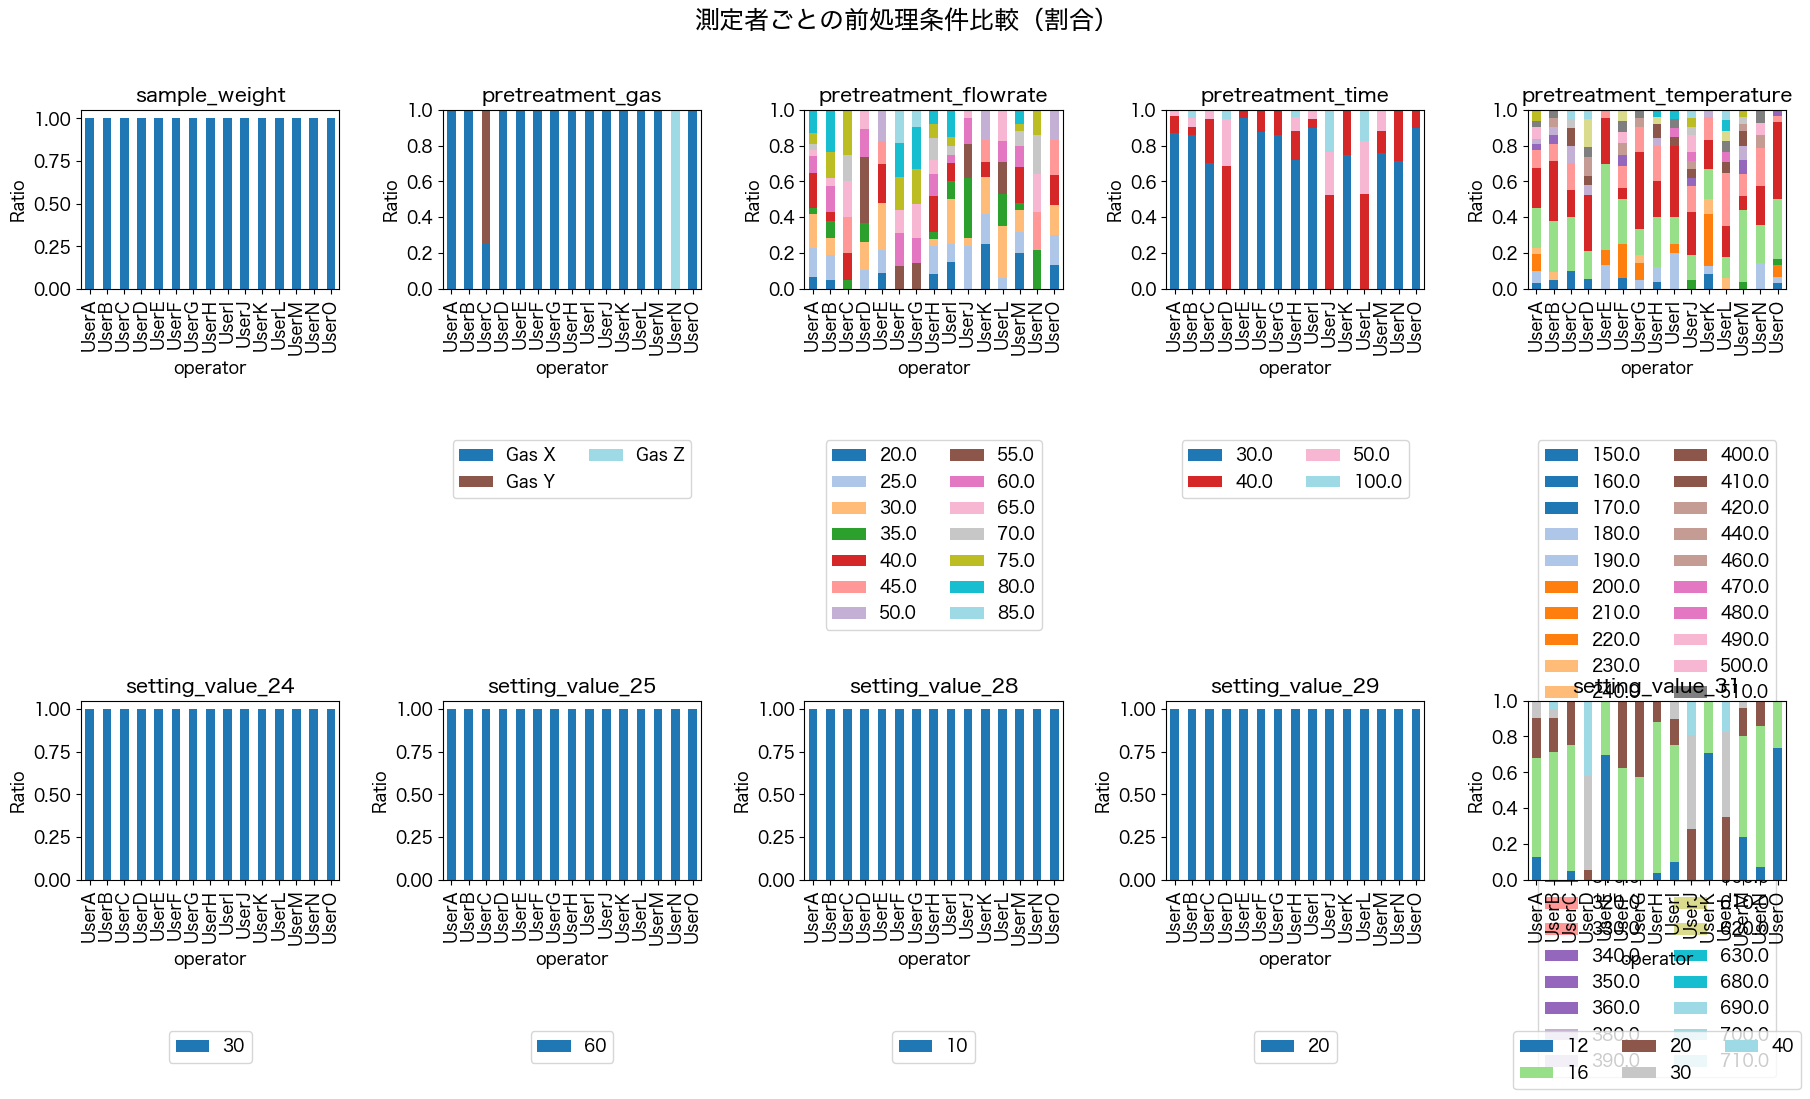

In [39]:
fig, axs = plt.subplots(2, 5, figsize=(22, 10))

conditions1 = ['sample_weight', 'pretreatment_gas', 'pretreatment_flowrate', 'pretreatment_time', 'pretreatment_temperature']
conditions2 = ['setting_value_24', 'setting_value_25', 'setting_value_28', 'setting_value_29', 'setting_value_31']

for i, condition in enumerate(conditions1):
    pivot_ratio = sampleA_sampleB_df.groupby("operator")[condition].value_counts(normalize=True).unstack(fill_value=0)
    pivot_ratio.plot(kind='bar', stacked=True, colormap='tab20', ax=axs[0, i])
    axs[0, i].set_title(condition)
    axs[0, i].set_ylabel('Ratio')
    axs[0, i].tick_params(axis='x', rotation=XLABEL_ANGLE)
    # axs[0, i].get_legend().remove()
    axs[0, i].legend(bbox_to_anchor=(0.5, -0.8), loc='upper center', ncol=2)
    

for i, condition in enumerate(conditions2):
    pivot_ratio = sampleA_sampleB_df.groupby("operator")[condition].value_counts(normalize=True).unstack(fill_value=0)
    pivot_ratio.plot(kind='bar', stacked=True, colormap='tab20', ax=axs[1, i])
    axs[1, i].set_title(condition)
    axs[1, i].set_ylabel('Ratio')
    axs[1, i].tick_params(axis='x', rotation=XLABEL_ANGLE)
    # axs[1, i].get_legend().remove()
    axs[1, i].legend(bbox_to_anchor=(0.5, -0.8), loc='upper center', ncol=3)

axs[0, 0].get_legend().remove()

fig.suptitle('測定者ごとの前処理条件比較（割合）', fontsize=18)
plt.subplots_adjust(wspace=0.4, hspace=2.3)

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_ratioOfConditionsByMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

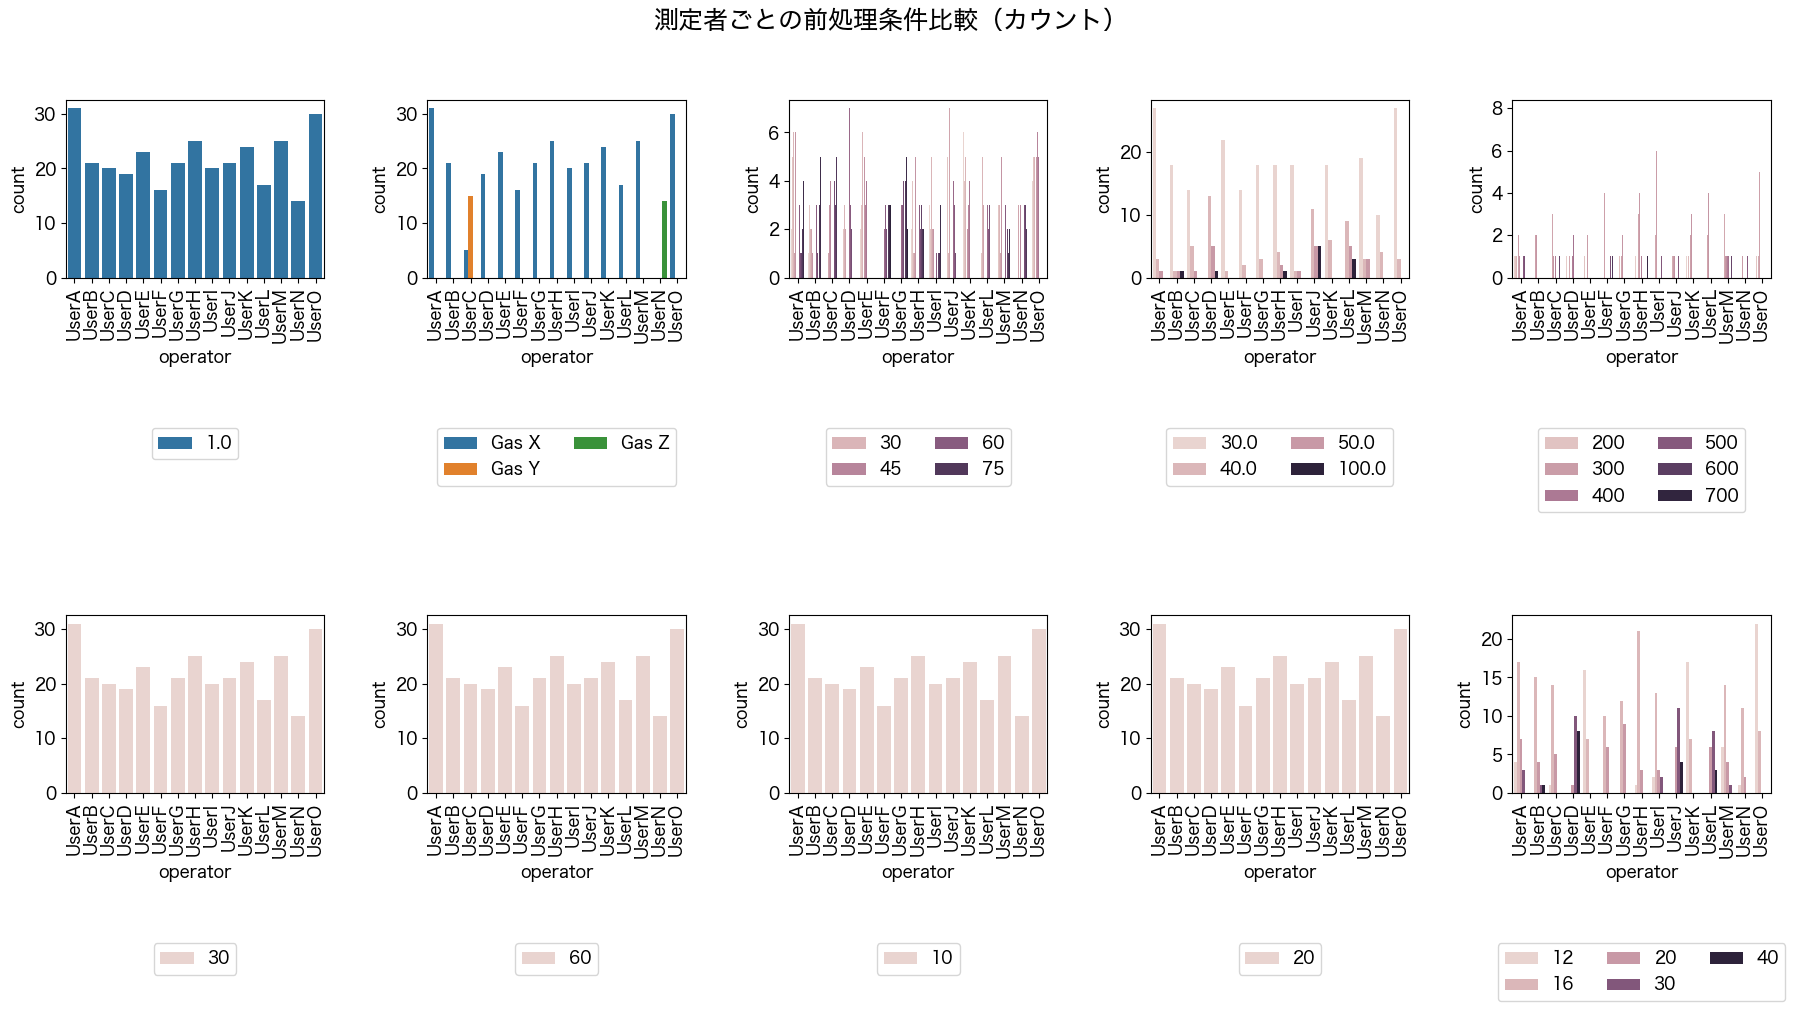

In [40]:
fig, axs = plt.subplots(2, 5, figsize=(22, 9))

conditions1 = ['sample_weight', 'pretreatment_gas', 'pretreatment_flowrate', 'pretreatment_time', 'pretreatment_temperature']
conditions2 = ['setting_value_24', 'setting_value_25', 'setting_value_28', 'setting_value_29', 'setting_value_31']
operator_order = sorted(sampleA_sampleB_df['operator'].unique())

for i, condition in enumerate(conditions1):
    sns.countplot(sampleA_sampleB_df, x='operator', hue=condition, order=operator_order, ax=axs[0, i])
    axs[0, i].tick_params(axis='x', rotation=XLABEL_ANGLE)
    axs[0, i].legend(bbox_to_anchor=(0.5, -0.8), loc='upper center', ncol=2)

for i, condition in enumerate(conditions2):
    sns.countplot(sampleA_sampleB_df, x='operator', hue=condition, order=operator_order, ax=axs[1, i])
    axs[1, i].tick_params(axis='x', rotation=XLABEL_ANGLE)
    axs[1, i].legend(bbox_to_anchor=(0.5, -0.8), loc='upper center', ncol=3)

fig.suptitle('測定者ごとの前処理条件比較（カウント）', fontsize=18)
plt.subplots_adjust(wspace=0.4, hspace=1.9)

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_countOfConditionsByMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

## 前処理条件設定値の分布

In [41]:
# pretreatment_time全体の値ごとの件数を確認
sampleA_sampleB_df['pretreatment_time'].value_counts()

pretreatment_time
30.0     223
40.0      69
50.0      24
100.0     11
Name: count, dtype: int64

In [42]:
# pretreatment_temperature全体の値ごとの件数を確認
sampleA_sampleB_df['pretreatment_temperature'].value_counts()

pretreatment_temperature
310.0    41
300.0    41
290.0    39
320.0    29
280.0    28
270.0    15
200.0    11
190.0     9
330.0     8
210.0     8
180.0     7
410.0     7
390.0     6
420.0     6
340.0     5
160.0     5
170.0     4
510.0     4
230.0     4
400.0     3
380.0     3
620.0     3
580.0     3
500.0     3
490.0     3
240.0     2
600.0     2
570.0     2
260.0     2
530.0     2
480.0     2
700.0     2
520.0     2
680.0     2
690.0     1
470.0     1
610.0     1
250.0     1
550.0     1
360.0     1
440.0     1
150.0     1
220.0     1
630.0     1
590.0     1
350.0     1
710.0     1
460.0     1
Name: count, dtype: int64

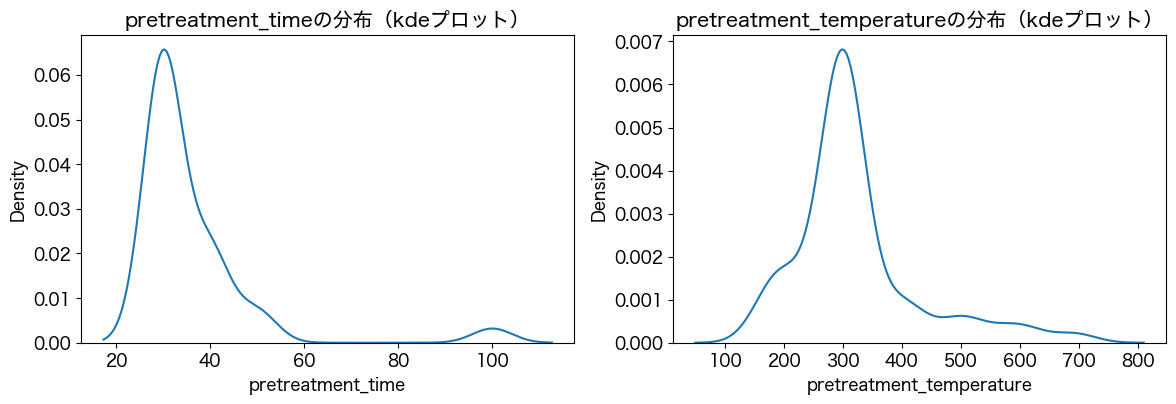

In [43]:
# pretreatment_timeとpretreatment_temperatureの分布をKDEプロットで可視化
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(sampleA_sampleB_df['pretreatment_time'], ax=axs[0])
sns.kdeplot(sampleA_sampleB_df['pretreatment_temperature'], ax=axs[1])
axs[0].set_title('pretreatment_timeの分布（kdeプロット）')
axs[1].set_title('pretreatment_temperatureの分布（kdeプロット）')
plt.show()

## Comparison by year

### ガス名の数値変換とyear列の追加

In [44]:
# 以降のヒートマップ作成用に、ガス名を数値化したコピーを作成し型を確認
# copy sampleA_sampleB_df
sampleA_sampleB_df_copy = sampleA_sampleB_df.copy()

# convert gas name to numeric values
sampleA_sampleB_df_copy['pretreatment_gas'] = sampleA_sampleB_df_copy['pretreatment_gas'].map(GAS_MAP)

sampleA_sampleB_df_copy.dtypes

operator                                               str
machine                                                str
filepath                                               str
sample_name                                            str
sample_type                                            str
sample_weight                                      float64
date                                        datetime64[us]
pretreatment_gas                                     int64
pretreatment_flowrate                              float64
pretreatment_time                                  float64
pretreatment_temperature                           float64
setting_value_24                                     int64
setting_value_25                                     int64
setting_value_28                                     int64
setting_value_29                                     int64
setting_value_31                                     int64
pulse_count                                          int

In [45]:
# 日付列から年を抽出し、date列でソートして確認
sampleA_sampleB_df_copy['year'] = sampleA_sampleB_df_copy['date'].dt.year
sampleA_sampleB_df_copy.sort_values('date')

,operator,machine,filepath,sample_name,sample_type,sample_weight,date,pretreatment_gas,pretreatment_flowrate,pretreatment_time,...,setting_value_28,setting_value_29,setting_value_31,pulse_count,measured_value_a8_total,measured_value_a8_total_per_weight,measured_value_a8_total_0to15,measured_value_a8_total_0to15_per_weight,measured_value_a8_total_0to15_ratio,year
4,UserK,MachineB,C:/MachineB/DATA/UserK/MethodA/sampleA_200105-...,sampleA_200105-MethodA-200106-0924,SampleA,1.0,2020-01-06 12:00:00,0,45.0,30.0,...,10,20,12,12,2192.9189,2192.9189,2192.9189,2192.9189,1.000000,2020
859,UserA,MachineA,C:/MachineA/DATA/UserA/MethodA/sampleA_200117-...,sampleA_200117-MethodA-200118-0914,SampleA,1.0,2020-01-18 12:00:00,0,40.0,30.0,...,10,20,20,16,2647.8567,2647.8567,2638.6775,2638.6775,0.996533,2020
602,UserB,MachineA,C:/MachineA/DATA/UserB/MethodA/sampleB_200120-...,sampleB_200120-MethodA-200202-1232,SampleB,1.0,2020-02-02 12:00:00,0,25.0,50.0,...,10,20,20,16,2102.0852,2102.0852,2099.7315,2099.7315,0.998880,2020
519,UserL,MachineA,C:/MachineA/DATA/UserL/MethodA/sampleB_200202-...,sampleB_200202-MethodA-200203-0920,SampleB,1.0,2020-02-03 12:00:00,0,35.0,40.0,...,10,20,30,16,2352.5436,2352.5436,2347.7472,2347.7472,0.997961,2020
603,UserB,MachineA,C:/MachineA/DATA/UserB/MethodA/sampleB_200125-...,sampleB_200125-MethodA-200204-1758,SampleB,1.0,2020-02-04 12:00:00,0,60.0,30.0,...,10,20,16,16,2158.0580,2158.0580,2158.0580,2158.0580,1.000000,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,UserB,MachineA,C:/MachineA/DATA/UserB/MethodA/sampleA_301021-...,sampleA_301021-MethodA-301205-1416,SampleA,1.0,2030-12-05 12:00:00,0,60.0,30.0,...,10,20,16,16,2549.5699,2549.5699,2549.5699,2549.5699,1.000000,2030
47,UserL,MachineB,C:/MachineB/DATA/UserL/MethodA/sampleA_301118-...,sampleA_301118-MethodA-301215-1437,SampleA,1.0,2030-12-15 12:00:00,0,30.0,40.0,...,10,20,40,16,2541.7911,2541.7911,2534.3825,2534.3825,0.997085,2030
107,UserB,MachineB,C:/MachineB/DATA/UserB/MethodA/sampleA_301224-...,sampleA_301224-MethodA-301225-1440,SampleA,1.0,2030-12-25 12:00:00,0,75.0,30.0,...,10,20,16,16,2736.1174,2736.1174,2736.1174,2736.1174,1.000000,2030
76,UserE,MachineB,C:/MachineB/DATA/UserE/MethodA/sampleA_301217-...,sampleA_301217-MethodA-310111-1157,SampleA,1.0,2031-01-11 12:00:00,0,30.0,30.0,...,10,20,12,12,2577.6668,2577.6668,2577.6668,2577.6668,1.000000,2031


### 測定者と年でグループ化

In [46]:
# 測定者×年ごとに各前処理条件の平均値を集計
# group by operator and year
grouped_sampleA_sampleB_df = sampleA_sampleB_df_copy.groupby(['operator', 'year'])[CONDITION_COLS].mean().reset_index()
grouped_sampleA_sampleB_df.head(10)

,operator,year,pretreatment_gas,pretreatment_flowrate,pretreatment_time,pretreatment_temperature,setting_value_24,setting_value_25,setting_value_28,setting_value_29,setting_value_31
0,UserA,2020,0.0,35.000000,30.0,295.000000,30.0,60.0,10.0,20.0,18.000000
1,UserA,2021,0.0,40.000000,30.0,250.000000,30.0,60.0,10.0,20.0,16.000000
2,UserA,2022,0.0,50.000000,35.0,255.000000,30.0,60.0,10.0,20.0,23.000000
3,UserA,2023,0.0,56.666667,30.0,293.333333,30.0,60.0,10.0,20.0,18.666667
4,UserA,2024,0.0,36.250000,35.0,245.000000,30.0,60.0,10.0,20.0,16.000000
5,UserA,2025,0.0,76.666667,30.0,456.666667,30.0,60.0,10.0,20.0,14.666667
6,UserA,2026,0.0,27.500000,32.5,295.000000,30.0,60.0,10.0,20.0,19.500000
7,UserA,2027,0.0,47.500000,30.0,435.000000,30.0,60.0,10.0,20.0,17.000000
8,UserA,2028,0.0,53.750000,32.5,282.500000,30.0,60.0,10.0,20.0,18.500000
9,UserA,2029,0.0,32.500000,30.0,345.000000,30.0,60.0,10.0,20.0,18.000000


### Heatmap operator vs year: pretreatment_time

In [47]:
# 測定者×年でpretreatment_timeの平均値をピボットしてヒートマップ用の表を作成
pivot_operator_year_pretreatment_time = grouped_sampleA_sampleB_df.pivot(index='operator', columns='year', values='pretreatment_time')
pivot_operator_year_pretreatment_time.head()

year,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
operator,,,,,,,,,,,,
UserA,30.0,30.0,35.0,30.0,35.0,30.0,32.5,30.0,32.500000,30.0,30.0,NaN
UserB,34.0,NaN,30.0,65.0,30.0,30.0,30.0,30.0,40.000000,30.0,30.0,NaN
UserC,NaN,30.0,NaN,40.0,35.0,NaN,36.0,32.5,30.000000,35.0,30.0,NaN
UserD,NaN,40.0,45.0,NaN,45.0,40.0,60.0,40.0,46.666667,50.0,40.0,NaN
UserE,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.000000,32.5,30.0,30.0


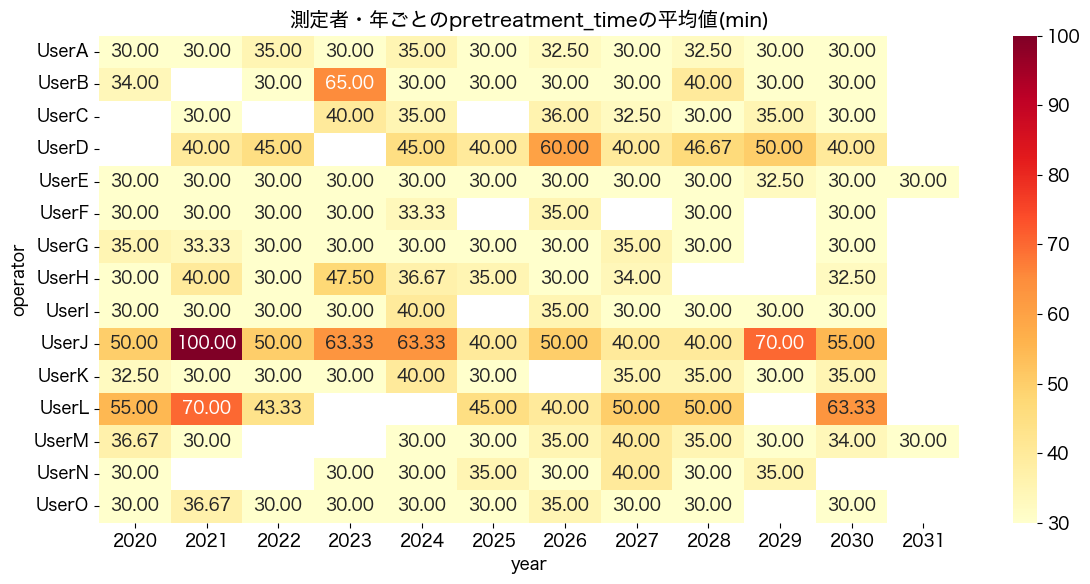

In [48]:
# 測定者・年ごとのpretreatment_time平均をヒートマップとして描画・保存
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_operator_year_pretreatment_time, annot=True, fmt='.2f', cmap="YlOrRd", ax=ax)

ax.set_title('測定者・年ごとのpretreatment_timeの平均値(min)')

plt.tight_layout()

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_pretreatmentTime_heatmap_YearVsMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

### Heatmap operator vs year: pretreatment_gas

In [49]:
# 測定者×年でpretreatment_gas（数値化済み）の平均値をピボットしてヒートマップ用の表を作成
pivot_operator_year_pretreatment_gas = grouped_sampleA_sampleB_df.pivot(index='operator', columns='year', values='pretreatment_gas')
pivot_operator_year_pretreatment_gas.head()

year,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
operator,,,,,,,,,,,,
UserA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,NaN
UserB,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,NaN
UserC,NaN,1.0,NaN,1.0,0.5,NaN,1.0,0.75,0.5,0.0,1.0,NaN
UserD,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.00,0.0,0.0,0.0,NaN
UserE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0


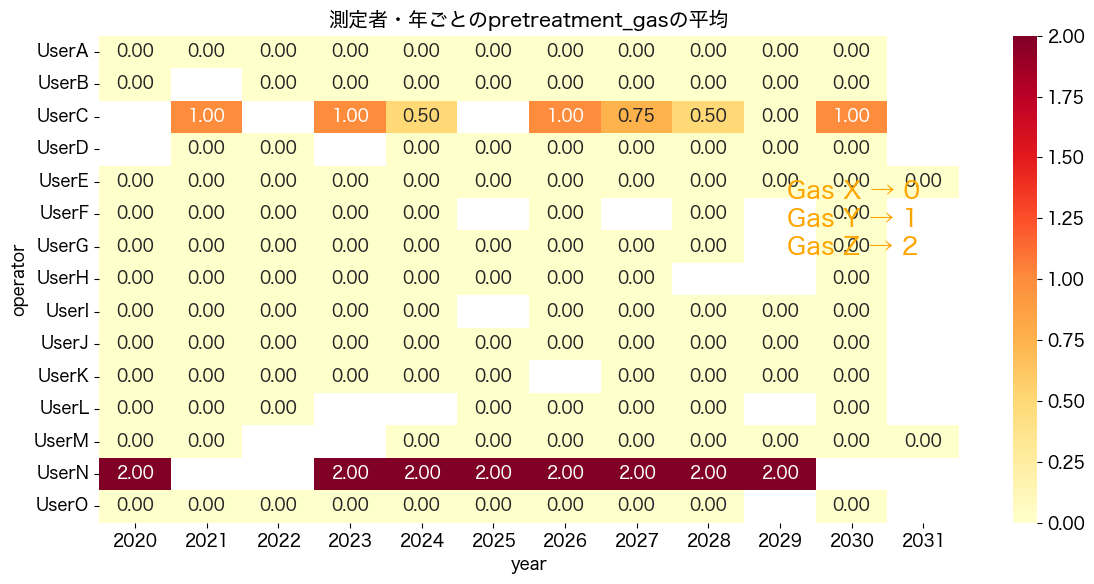

In [50]:
# 測定者・年ごとのpretreatment_gas平均をヒートマップとして描画・保存
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_operator_year_pretreatment_gas, annot=True, fmt='.2f', cmap="YlOrRd", ax=ax)

ax.annotate("Gas X → 0\nGas Y → 1\nGas Z → 2", xy=(0.80, 0.55), 
            xycoords='axes fraction', color="orange", fontsize=18)

ax.set_title('測定者・年ごとのpretreatment_gasの平均')

plt.tight_layout()

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_pretreatmentGas_heatmap_YearVsMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

### Heatmap operator vs year: pretreatment_temperature

In [51]:
# 測定者×年でpretreatment_temperatureの平均値をピボットしてヒートマップ用の表を作成
pivot_operator_year_pretreatment_temp = grouped_sampleA_sampleB_df.pivot(index='operator', columns='year', values='pretreatment_temperature')
pivot_operator_year_pretreatment_temp.head()

year,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
operator,,,,,,,,,,,,
UserA,295.0,250.0,255.0,293.333333,245.0,456.666667,295.000000,435.0,282.5,345.0,310.0,NaN
UserB,294.0,NaN,310.0,390.000000,420.0,300.000000,290.000000,305.0,300.0,235.0,315.0,NaN
UserC,NaN,245.0,NaN,290.000000,315.0,NaN,368.000000,282.5,540.0,300.0,360.0,NaN
UserD,NaN,270.0,410.0,NaN,455.0,390.000000,336.666667,560.0,330.0,170.0,360.0,NaN
UserE,270.0,310.0,250.0,290.000000,310.0,296.666667,263.333333,190.0,180.0,287.5,290.0,300.0


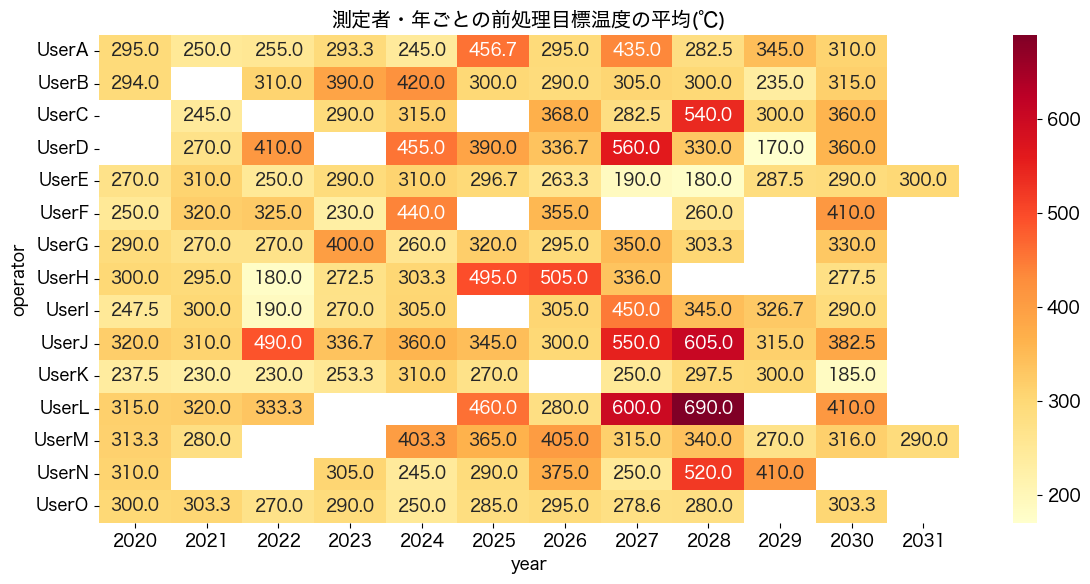

In [52]:
# 測定者・年ごとの前処理目標温度の平均をヒートマップとして描画・保存
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_operator_year_pretreatment_temp, annot=True, fmt='.1f', cmap="YlOrRd", ax=ax)

ax.set_title('測定者・年ごとの前処理目標温度の平均(℃)')

plt.tight_layout()

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_pretreatmentTemp_heatmap_YearVsMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

### Heatmap operator vs year: Pulse introduction number

In [53]:
# 測定者×年でsetting_value_31（最大パルス回数）の平均値をピボットしてヒートマップ用の表を作成
pivot_operator_year_pretreatment_pulsenumber = grouped_sampleA_sampleB_df.pivot(index='operator', columns='year', values='setting_value_31')
pivot_operator_year_pretreatment_pulsenumber.head()

year,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031
operator,,,,,,,,,,,,
UserA,18.0,16.0,23.000000,18.666667,16.0,14.666667,19.500000,17.0,18.5,18.0,16.0,NaN
UserB,19.6,NaN,20.000000,16.000000,16.0,16.000000,28.000000,16.0,16.0,18.0,17.0,NaN
UserC,NaN,18.0,NaN,16.000000,18.0,NaN,16.000000,16.0,16.0,20.0,16.0,NaN
UserD,NaN,40.0,30.000000,NaN,40.0,40.000000,33.333333,32.5,30.0,30.0,35.0,NaN
UserE,12.0,16.0,14.666667,12.000000,16.0,12.000000,12.000000,14.0,12.0,14.0,12.0,12.0


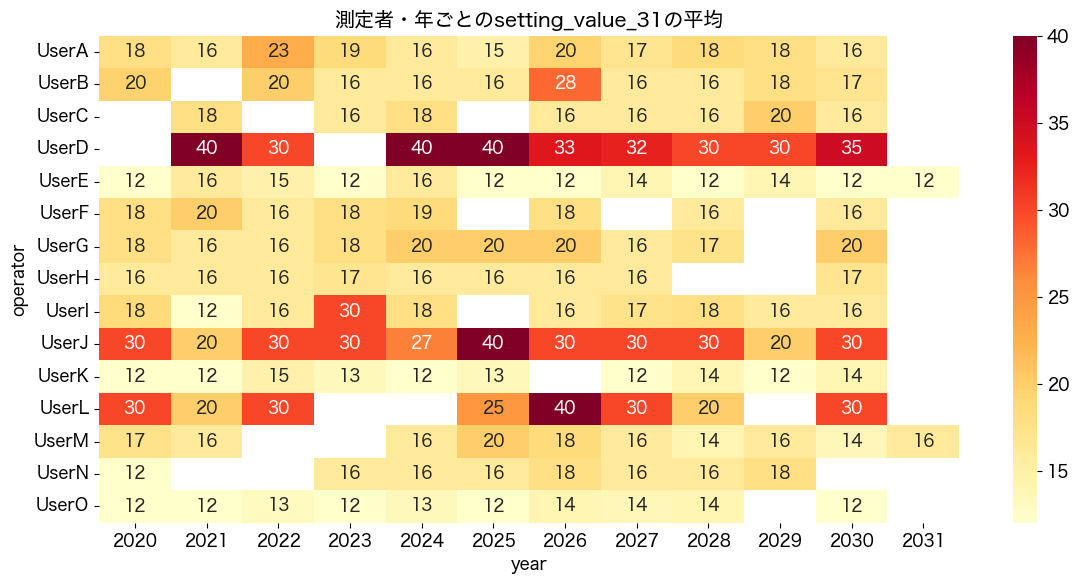

In [54]:
# 測定者・年ごとのsetting_value_31平均をヒートマップとして描画・保存
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pivot_operator_year_pretreatment_pulsenumber, annot=True, fmt='.0f', cmap="YlOrRd", ax=ax)

ax.set_title('測定者・年ごとのsetting_value_31の平均')

plt.tight_layout()

if IS_SAVEGRAPH:
    os.makedirs(os.path.join(OUTPUT_ROOT, "Graph"), exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(OUTPUT_ROOT, f'Graph/MethodA_maxPulseTime_heatmap_YearVsMeasurer_created{current_time}.png'), bbox_inches="tight")
else:
    plt.show()

## MachineA: Pretreatment temperature

In [55]:
# 装置がMachineAのデータのみに絞り込む
sampleA_sampleB_df_machineA = sampleA_sampleB_df[sampleA_sampleB_df['machine'] == 'MachineA']

In [56]:
# 絞り込んだデータの先頭数行を確認
sampleA_sampleB_df_machineA.head()

,operator,machine,filepath,sample_name,sample_type,sample_weight,date,pretreatment_gas,pretreatment_flowrate,pretreatment_time,...,setting_value_25,setting_value_28,setting_value_29,setting_value_31,pulse_count,measured_value_a8_total,measured_value_a8_total_per_weight,measured_value_a8_total_0to15,measured_value_a8_total_0to15_per_weight,measured_value_a8_total_0to15_ratio
479,UserK,MachineA,C:/MachineA/DATA/UserK/MethodA/sampleB_221028-...,sampleB_221028-MethodA-221102-1255,SampleB,1.0,2022-11-02 12:00:00,Gas X,45.0,30.0,...,60,10,20,12,12,2659.3910,2659.3910,2659.3910,2659.3910,1.0
481,UserK,MachineA,C:/MachineA/DATA/UserK/MethodA/sampleB_251105-...,sampleB_251105-MethodA-251218-1059,SampleB,1.0,2025-12-18 12:00:00,Gas X,30.0,30.0,...,60,10,20,12,12,3138.5390,3138.5390,3138.5390,3138.5390,1.0
485,UserK,MachineA,C:/MachineA/DATA/UserK/MethodA/sampleB_280707-...,sampleB_280707-MethodA-280711-1543,SampleB,1.0,2028-07-11 12:00:00,Gas X,30.0,30.0,...,60,10,20,16,16,2162.7432,2162.7432,2162.7432,2162.7432,1.0
486,UserK,MachineA,C:/MachineA/DATA/UserK/MethodA/sampleA_230812-...,sampleA_230812-MethodA-230813-0910,SampleA,1.0,2023-08-13 12:00:00,Gas X,25.0,30.0,...,60,10,20,12,12,2775.2225,2775.2225,2775.2225,2775.2225,1.0
487,UserK,MachineA,C:/MachineA/DATA/UserK/MethodA/sampleB_240528-...,sampleB_240528-MethodA-240529-1220,SampleB,1.0,2024-05-29 12:00:00,Gas X,20.0,40.0,...,60,10,20,12,12,2084.0952,2084.0952,2084.0952,2084.0952,1.0


In [57]:
# MachineAを使用した測定者の一覧を確認
sampleA_sampleB_df_machineA['operator'].unique()

<StringArray>
['UserK', 'UserL', 'UserE', 'UserB', 'UserC', 'UserD', 'UserM', 'UserJ',
 'UserO', 'UserH', 'UserA', 'UserF', 'UserG', 'UserI', 'UserN']
Length: 15, dtype: str

In [58]:
# MachineA全体での前処理温度の値ごとの件数を確認
sampleA_sampleB_df_machineA['pretreatment_temperature'].value_counts()

pretreatment_temperature
310.0    25
300.0    25
290.0    17
280.0    15
320.0    14
200.0     8
420.0     6
410.0     5
180.0     5
330.0     5
230.0     4
210.0     4
190.0     4
510.0     3
270.0     3
160.0     2
390.0     2
700.0     2
170.0     2
520.0     2
400.0     2
340.0     2
680.0     2
490.0     2
150.0     1
220.0     1
380.0     1
630.0     1
570.0     1
620.0     1
590.0     1
350.0     1
710.0     1
260.0     1
480.0     1
530.0     1
460.0     1
240.0     1
Name: count, dtype: int64

In [59]:
# UserAに絞った前処理温度の値ごとの件数を確認
sampleA_sampleB_df_machineA[(sampleA_sampleB_df_machineA['operator'] == 'UserA')]['pretreatment_temperature'].value_counts()

pretreatment_temperature
280.0    3
290.0    3
200.0    3
300.0    2
310.0    2
230.0    1
180.0    1
330.0    1
490.0    1
340.0    1
530.0    1
Name: count, dtype: int64

In [60]:
# UserBに絞った前処理温度の値ごとの件数を確認
sampleA_sampleB_df_machineA[(sampleA_sampleB_df_machineA['operator'] == 'UserB')]['pretreatment_temperature'].value_counts()

pretreatment_temperature
300.0    3
310.0    3
280.0    2
390.0    1
160.0    1
420.0    1
510.0    1
230.0    1
320.0    1
Name: count, dtype: int64

In [61]:
# UserCに絞った前処理温度の値ごとの件数を確認
sampleA_sampleB_df_machineA[(sampleA_sampleB_df_machineA['operator'] == 'UserC')]['pretreatment_temperature'].value_counts()

pretreatment_temperature
330.0    2
700.0    1
570.0    1
280.0    1
320.0    1
300.0    1
310.0    1
Name: count, dtype: int64

## Comparison of conditions

In [62]:
# sampleA_sampleB_dfの列名一覧を確認
sampleA_sampleB_df.columns

Index(['operator', 'machine', 'filepath', 'sample_name', 'sample_type',
       'sample_weight', 'date', 'pretreatment_gas', 'pretreatment_flowrate',
       'pretreatment_time', 'pretreatment_temperature', 'setting_value_24',
       'setting_value_25', 'setting_value_28', 'setting_value_29',
       'setting_value_31', 'pulse_count', 'measured_value_a8_total',
       'measured_value_a8_total_per_weight', 'measured_value_a8_total_0to15',
       'measured_value_a8_total_0to15_per_weight',
       'measured_value_a8_total_0to15_ratio'],
      dtype='str')

In [63]:
# 測定者×各前処理条件の組み合わせごとの件数を集計
grouped_sampleA_sampleB_df = sampleA_sampleB_df.groupby(["operator"] + CONDITION_COLS).size().reset_index(name="count")
grouped_sampleA_sampleB_df

,operator,pretreatment_gas,pretreatment_flowrate,pretreatment_time,pretreatment_temperature,setting_value_24,setting_value_25,setting_value_28,setting_value_29,setting_value_31,count
0,UserA,Gas X,20.0,30.0,190.0,30,60,10,20,12,1
1,UserA,Gas X,20.0,30.0,280.0,30,60,10,20,16,1
2,UserA,Gas X,25.0,30.0,200.0,30,60,10,20,20,1
3,UserA,Gas X,25.0,30.0,310.0,30,60,10,20,30,1
4,UserA,Gas X,25.0,30.0,390.0,30,60,10,20,16,1
...,...,...,...,...,...,...,...,...,...,...,...
308,UserO,Gas X,50.0,30.0,170.0,30,60,10,20,12,1
309,UserO,Gas X,50.0,30.0,190.0,30,60,10,20,12,1
310,UserO,Gas X,50.0,30.0,260.0,30,60,10,20,12,1
311,UserO,Gas X,50.0,30.0,290.0,30,60,10,20,12,1


In [64]:
# 測定者ごとの前処理流量の値ごとの件数を集計
summary = sampleA_sampleB_df.groupby('operator')['pretreatment_flowrate'].value_counts()
summary

operator  pretreatment_flowrate
UserA     40.0                     6
          30.0                     6
          25.0                     5
          80.0                     4
          60.0                     3
                                  ..
UserO     25.0                     5
          40.0                     5
          50.0                     5
          30.0                     5
          20.0                     4
Name: count, Length: 106, dtype: int64

In [65]:
# 測定者×前処理温度のクロス集計表を作成
pd.crosstab(sampleA_sampleB_df["operator"], sampleA_sampleB_df["pretreatment_temperature"])

pretreatment_temperature,150.0,160.0,170.0,180.0,190.0,200.0,210.0,220.0,230.0,240.0,...,580.0,590.0,600.0,610.0,620.0,630.0,680.0,690.0,700.0,710.0
operator,,,,,,,,,,,,,,,,,,,,,
UserA,0,1,0,1,1,3,0,0,1,0,...,2,0,0,0,0,0,0,0,0,0
UserB,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
UserC,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UserD,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,1,0
UserE,0,0,0,2,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UserF,0,0,1,0,0,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,0
UserG,0,0,0,0,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
UserH,0,0,1,1,1,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
UserI,0,0,0,2,2,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [66]:
# 各前処理条件について、測定者ごとのユニーク値数を確認
for col in CONDITION_COLS:
    print(f"\nUnique values of {col} per scientist:")
    print(sampleA_sampleB_df.groupby("operator")[col].nunique())


Unique values of pretreatment_gas per scientist:
operator
UserA    1
UserB    1
UserC    2
UserD    1
UserE    1
UserF    1
UserG    1
UserH    1
UserI    1
UserJ    1
UserK    1
UserL    1
UserM    1
UserN    1
UserO    1
Name: pretreatment_gas, dtype: int64

Unique values of pretreatment_flowrate per scientist:
operator
UserA    10
UserB     9
UserC     6
UserD     6
UserE     6
UserF     6
UserG     6
UserH    10
UserI     9
UserJ     6
UserK     6
UserL     6
UserM     9
UserN     5
UserO     6
Name: pretreatment_flowrate, dtype: int64

Unique values of pretreatment_time per scientist:
operator
UserA    3
UserB    4
UserC    3
UserD    3
UserE    2
UserF    2
UserG    2
UserH    4
UserI    3
UserJ    3
UserK    2
UserL    3
UserM    3
UserN    2
UserO    2
Name: pretreatment_time, dtype: int64

Unique values of pretreatment_temperature per scientist:
operator
UserA    17
UserB    12
UserC    13
UserD    11
UserE    10
UserF    11
UserG    13
UserH    14
UserI    11
UserJ    16
Use